In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path
from sklearn.utils import resample

In [2]:
# Load dataset
df = pd.read_excel(r"C:\Users\User\OneDrive\Documents\Brazilian-Ecommerce-Cleaned.xlsx", parse_dates=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
print("Done!")

Done!


All required columns available ✅

Pearson Correlation Matrix:

                      payment_value  payment_installments     price  \
payment_value              1.000000              0.274283  0.736678   
payment_installments       0.274283              1.000000  0.279435   
price                      0.736678              0.279435  1.000000   
freight_value              0.372610              0.186492  0.414980   

                      freight_value  
payment_value              0.372610  
payment_installments       0.186492  
price                      0.414980  
freight_value              1.000000  

Key Correlation — payment_installments vs payment_value: 0.2743


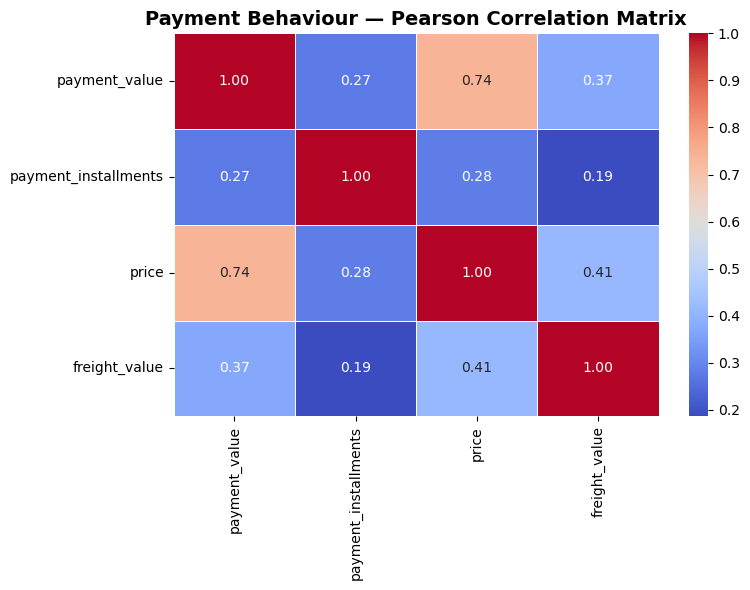

Saved: payment_correlation.png ✅

Customer-level aggregation sample:
                        customer_id  total_spend  avg_installments  avg_price  \
0  00012a2ce6f8dcda20d059ce98491703       114.74               8.0      89.80   
1  000161a058600d5901f007fab4c27140        67.41               5.0      54.90   
2  0001fd6190edaaf884bcaf3d49edf079       195.42              10.0     179.99   
3  0002414f95344307404f0ace7a26f1d5       179.35               1.0     149.90   
4  000379cdec625522490c315e70c7a9fb       107.01               1.0      93.00   

   avg_freight predominant_payment_type  
0        24.94              credit_card  
1        12.51              credit_card  
2        15.43              credit_card  
3        29.45                   boleto  
4        14.01                   boleto  

Total customers: 95,128


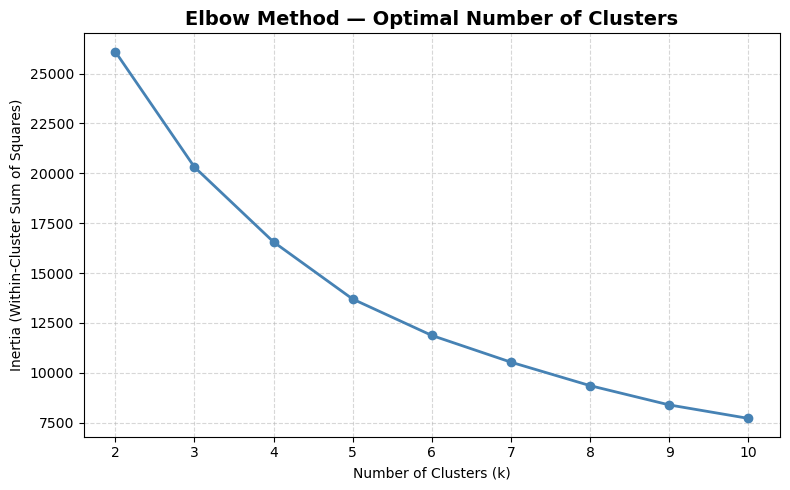

Saved: elbow_method.png ✅


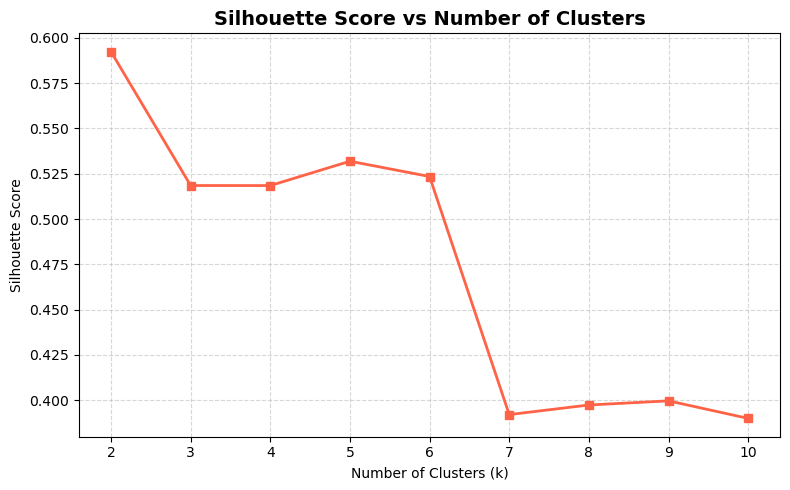

Saved: silhouette_scores.png ✅

Silhouette Scores per k:
  k=2  ->  0.5923
  k=3  ->  0.5185
  k=4  ->  0.5184
  k=5  ->  0.5319
  k=6  ->  0.5235
  k=7  ->  0.3921
  k=8  ->  0.3974
  k=9  ->  0.3997
  k=10  ->  0.3900

Optimal k (highest silhouette score): 2

Final Model — Silhouette Score (k=2): 0.5833

Cluster Distribution:
cluster
0    16467
1    78661
Name: count, dtype: int64

Cluster Profile Summary (mean values):
         total_spend  avg_installments  avg_price  avg_freight
cluster                                                       
0             537.32              7.36     320.45        34.68
1             135.80              1.99      84.46        17.15

Payment Type Distribution per Cluster:
 cluster predominant_payment_type  count
       0                   boleto    704
       0              credit_card  15666
       0               debit_card     49
       0                  voucher     48
       1                   boleto  18222
       1              credit_card  5

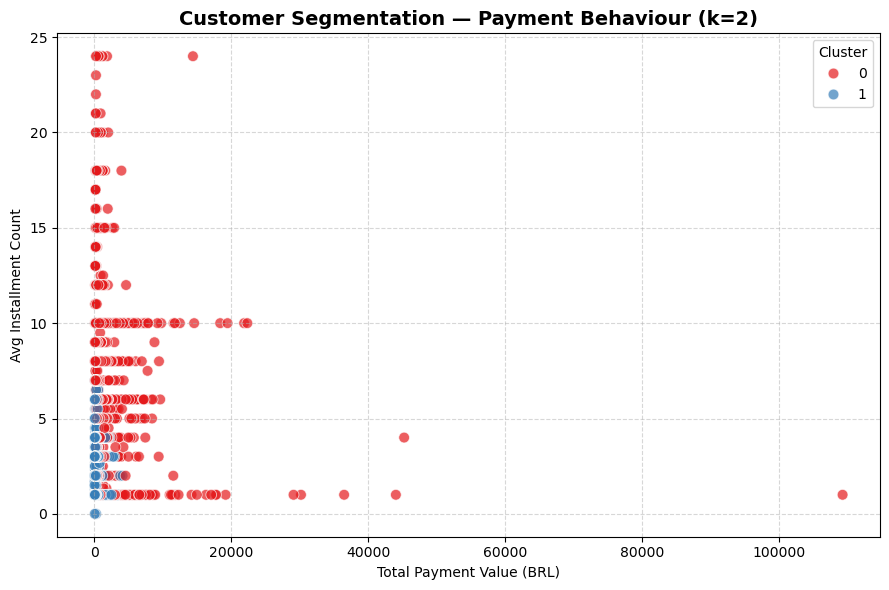

Saved: customer_segments.png ✅


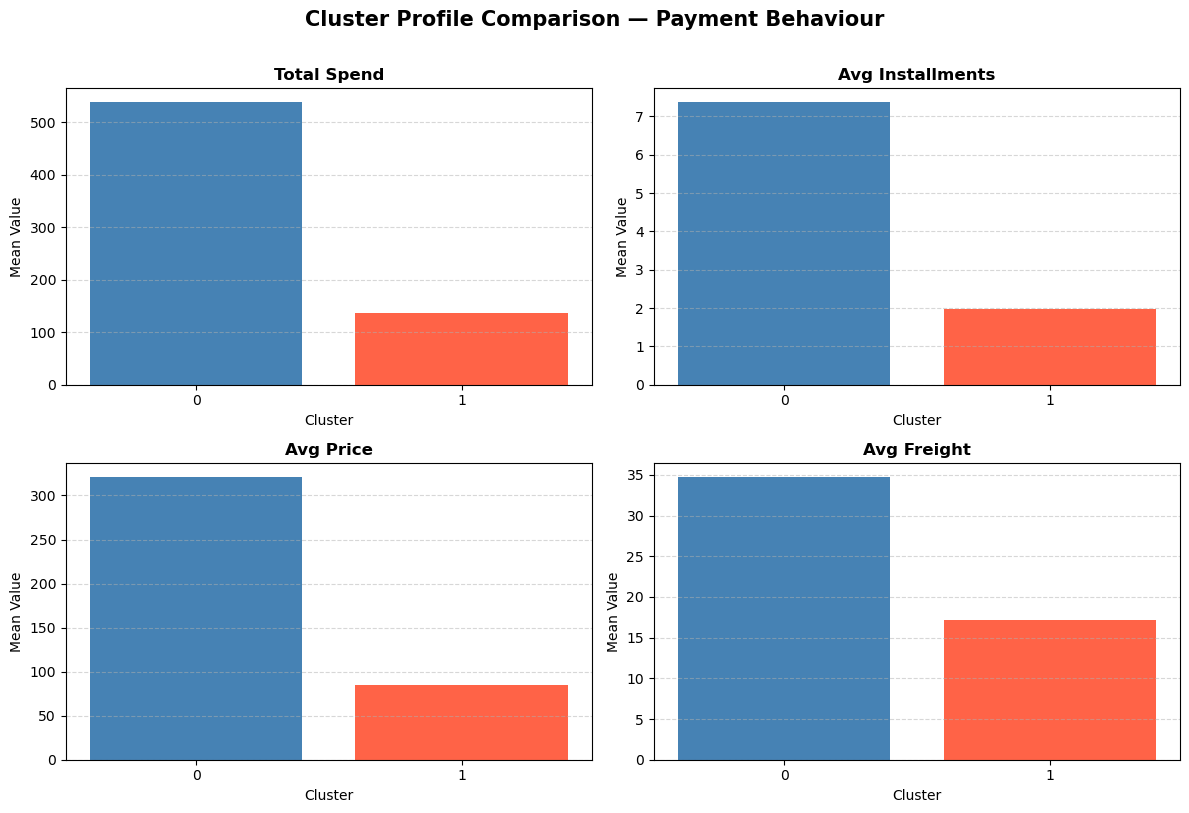

Saved: cluster_profiles.png ✅

✅ Model 5 — Payment Behaviour Analysis complete.


In [8]:

output_dir = Path(r"D:\Olist_Analysis_Project\Outputs\Module5")
output_dir.mkdir(parents=True, exist_ok=True)

# =============================================================
# STEP 1 — CHECK REQUIRED COLUMNS
# =============================================================

required_cols = [
    "payment_value",
    "payment_installments",
    "payment_type",
    "price",
    "freight_value",
    "customer_id"
]

missing = [col for col in required_cols if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns available ✅")

# =============================================================
# STEP 2 — PEARSON CORRELATION ANALYSIS
# (payment_installments vs payment_value — as per synopsis)
# =============================================================

corr_df = df[[
    "payment_value",
    "payment_installments",
    "price",
    "freight_value"
]].corr(method="pearson")

print("\nPearson Correlation Matrix:\n")
print(corr_df)

# Highlight the key relationship specified in synopsis
key_corr = corr_df.loc["payment_installments", "payment_value"]
print(f"\nKey Correlation — payment_installments vs payment_value: {key_corr:.4f}")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Payment Behaviour — Pearson Correlation Matrix",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(output_dir / "payment_correlation.png", dpi=300)
plt.show()
print("Saved: payment_correlation.png ✅")

# =============================================================
# STEP 3 — PER-CUSTOMER AGGREGATION
# (total spend, avg installments, predominant payment method)
# =============================================================

# Predominant payment method per customer
payment_mode = (
    df.groupby("customer_id")["payment_type"]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={"payment_type": "predominant_payment_type"})
)

# Numeric aggregates per customer
customer_data = df.groupby("customer_id").agg(
    total_spend      = ("payment_value",        "sum"),
    avg_installments = ("payment_installments", "mean"),
    avg_price        = ("price",                "mean"),
    avg_freight      = ("freight_value",        "mean")
).reset_index()

# Merge predominant payment method
customer_data = customer_data.merge(payment_mode, on="customer_id")

print("\nCustomer-level aggregation sample:")
print(customer_data.head())
print(f"\nTotal customers: {len(customer_data):,}")

# =============================================================
# STEP 4 — FEATURE SCALING
# =============================================================

features = ["total_spend", "avg_installments", "avg_price", "avg_freight"]
X = customer_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================================================
# STEP 5 — ELBOW METHOD (determine optimal k)
# Uses a 10,000-record sample for computational efficiency
# Final model is trained on the full dataset
# =============================================================

X_scaled_sample = resample(X_scaled, n_samples=10000, random_state=42)

inertia    = []
silhouette = []
k_range    = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_sample)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled_sample, labels))

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Optimal Number of Clusters",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "elbow_method.png", dpi=300)
plt.show()
print("Saved: elbow_method.png ✅")

# =============================================================
# STEP 6 — SILHOUETTE SCORES (validate optimal k)
# =============================================================

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette, marker="s", color="tomato", linewidth=2)
plt.title("Silhouette Score vs Number of Clusters",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "silhouette_scores.png", dpi=300)
plt.show()
print("Saved: silhouette_scores.png ✅")

# Print scores for reference
print("\nSilhouette Scores per k:")
for k, s in zip(k_range, silhouette):
    print(f"  k={k}  ->  {s:.4f}")

# Identify best k by highest silhouette score
optimal_k = list(k_range)[silhouette.index(max(silhouette))]
print(f"\nOptimal k (highest silhouette score): {optimal_k}")

# =============================================================
# STEP 7 — FINAL K-MEANS WITH OPTIMAL k (full dataset)
# =============================================================

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_data["cluster"] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, customer_data["cluster"])
print(f"\nFinal Model — Silhouette Score (k={optimal_k}): {final_silhouette:.4f}")

print("\nCluster Distribution:")
print(customer_data["cluster"].value_counts().sort_index())

# =============================================================
# STEP 8 — CLUSTER PROFILE SUMMARY
# =============================================================

cluster_summary = customer_data.groupby("cluster")[features].mean().round(2)
print("\nCluster Profile Summary (mean values):")
print(cluster_summary)

# Payment type distribution per cluster
payment_dist = (
    customer_data.groupby(["cluster", "predominant_payment_type"])
    .size()
    .reset_index(name="count")
)
print("\nPayment Type Distribution per Cluster:")
print(payment_dist.to_string(index=False))

# =============================================================
# STEP 9 — CLUSTER SCATTER PLOT
# =============================================================

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=customer_data,
    x="total_spend",
    y="avg_installments",
    hue="cluster",
    palette="Set1",
    s=60,
    alpha=0.7
)
plt.title(f"Customer Segmentation — Payment Behaviour (k={optimal_k})",
          fontsize=14, fontweight="bold")
plt.xlabel("Total Payment Value (BRL)")
plt.ylabel("Avg Installment Count")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "customer_segments.png", dpi=300)
plt.show()
print("Saved: customer_segments.png ✅")

# =============================================================
# STEP 10 — CLUSTER PROFILE BAR CHART
# =============================================================

cluster_summary_plot = customer_data.groupby("cluster")[features].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ["steelblue", "tomato", "seagreen", "darkorange",
          "mediumpurple", "goldenrod", "teal"]

for i, feat in enumerate(features):
    axes[i].bar(
        cluster_summary_plot.index.astype(str),
        cluster_summary_plot[feat],
        color=colors[:optimal_k]
    )
    axes[i].set_title(feat.replace("_", " ").title(), fontweight="bold")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Mean Value")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Cluster Profile Comparison — Payment Behaviour",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(output_dir / "cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cluster_profiles.png ✅")

print("\n✅ Model 5 — Payment Behaviour Analysis complete.")